# Deep Learning Lizard Challenge - score boost

Deze notebook volgt de PowerPoint: EDA, eigen CNN, transfer learning, data augmentation, training plots, confusion matrix en een geldige Kaggle submission.

Score-focus: sterker EfficientNetV2-model, fine-tuning met lage learning rate, validatiegestuurde modelkeuze en TTA voor stabielere Kaggle-voorspellingen.

In [1]:
from pathlib import Path
import random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__)

I0000 00:00:1778663801.621896   45140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778663802.262344   45140 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778663804.542173   45140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Data inlezen

In [2]:
BASE_DIR = Path("lizard-prediction-thomas-more")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"

train_df = pd.read_csv(BASE_DIR / "train.csv")
test_df = pd.read_csv(BASE_DIR / "test.csv")
sample_sub = pd.read_csv(BASE_DIR / "sample_submission.csv")

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(len(train_df), "trainbeelden")
print(len(test_df), "testbeelden")
print(NUM_CLASSES, "klassen")
for i, name in enumerate(CLASS_NAMES):
    print(i, name)
train_df.head()

1334 trainbeelden
326 testbeelden
7 klassen
0 Black_spiny_tailed_iguana
1 Brown_anole
2 Cuban_knight_anole
3 Desert_iguana
4 Green_anole
5 Green_iguana
6 Lesser_Antillean_iguana


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


In [3]:
def resolve_train_path(row):
    label = int(row["label"])
    class_dir = TRAIN_DIR / CLASS_NAMES[label]
    raw_id = str(row["id"])
    candidates = [class_dir / raw_id, class_dir / f"{raw_id}.jpg", class_dir / f"{raw_id}.jpeg", class_dir / f"{raw_id}.png"]
    for path in candidates:
        if path.exists():
            return str(path)
    stem = Path(raw_id).stem
    hits = list(class_dir.glob(stem + ".*"))
    if hits:
        return str(hits[0])
    raise FileNotFoundError(raw_id)

def resolve_test_path(image_id):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = TEST_DIR / f"{int(image_id)}{ext}"
        if path.exists():
            return str(path)
    raise FileNotFoundError(image_id)

train_df["path"] = train_df.apply(resolve_train_path, axis=1)
test_df["path"] = test_df["id"].apply(resolve_test_path)
assert train_df["path"].map(lambda p: Path(p).exists()).all()
assert test_df["path"].map(lambda p: Path(p).exists()).all()
print("Alle image paths gevonden")

Alle image paths gevonden


## 2. EDA

De klassen zijn licht uit balans. Daarom gebruiken we later `class_weight`.

,label,class_name,count
0,0,Black_spiny_tailed_iguana,199
1,1,Brown_anole,193
2,2,Cuban_knight_anole,189
3,3,Desert_iguana,183
4,4,Green_anole,178
5,5,Green_iguana,196
6,6,Lesser_Antillean_iguana,196


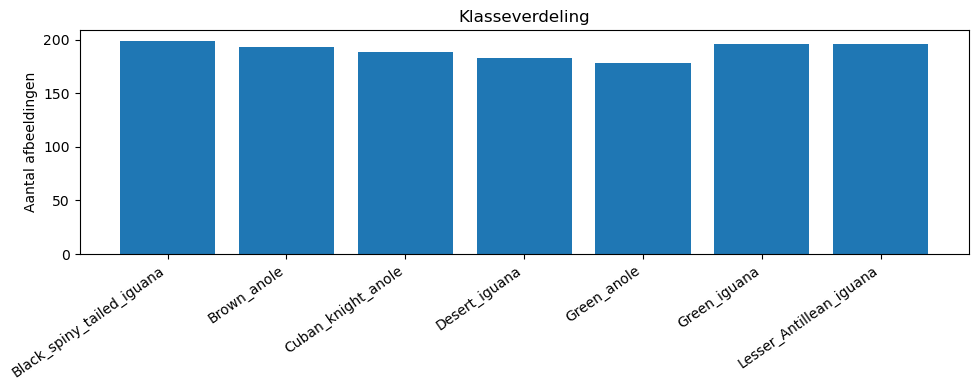

In [4]:
class_counts = train_df["label"].value_counts().sort_index()
eda = pd.DataFrame({"label": class_counts.index, "class_name": [CLASS_NAMES[i] for i in class_counts.index], "count": class_counts.values})
display(eda)

plt.figure(figsize=(10,4))
plt.bar(eda["class_name"], eda["count"])
plt.xticks(rotation=35, ha="right")
plt.title("Klasseverdeling")
plt.ylabel("Aantal afbeeldingen")
plt.tight_layout()
plt.show()

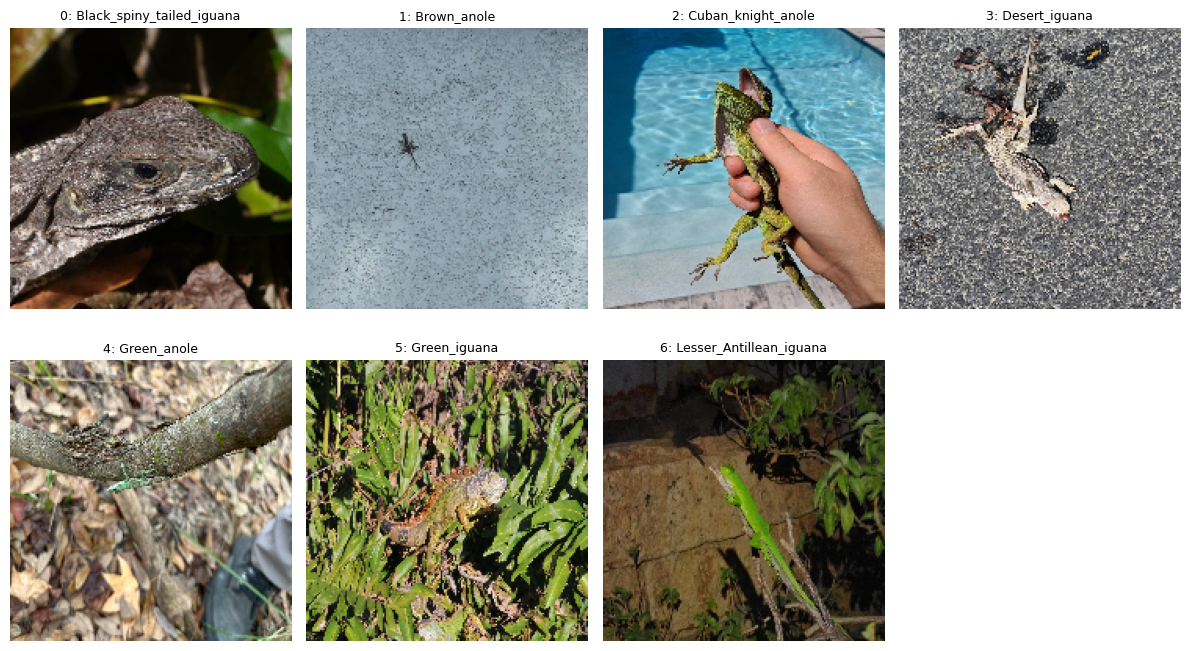

In [5]:
plt.figure(figsize=(12,7))
for label in range(NUM_CLASSES):
    row = train_df[train_df["label"] == label].sample(1, random_state=SEED).iloc[0]
    img = keras.utils.load_img(row["path"], target_size=(180, 180))
    plt.subplot(2, 4, label + 1)
    plt.imshow(img)
    plt.title(f"{label}: {CLASS_NAMES[label]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Stratified split en class weights

In [6]:
train_split, val_split = train_test_split(train_df, test_size=0.20, random_state=SEED, stratify=train_df["label"])
print("train", len(train_split), "validatie", len(val_split))
print(val_split["label"].value_counts().sort_index())


train 1067 validatie 267
label
0    40
1    39
2    38
3    37
4    35
5    39
6    39
Name: count, dtype: int64


## 3b. Cropcontrole op alle klassen

Deze sectie controleert de volledige trainingsset op beelden waar een crop nuttig kan zijn: kleine hagedis, veel achtergrond, slechte centrering of een drukke achtergrond. Alle klassen krijgen dezelfde controle.

Belangrijk tegen data leakage: automatische crop-kopieen worden pas na de stratified split gemaakt en alleen aan `train_split` toegevoegd. Omdat de eenvoudige saliency-heuristiek geen betrouwbare object detector is, worden twijfelgevallen vooral getoond voor manuele review. `val_split` en `test` blijven onaangeraakt.


In [7]:
# Instellingen voor cropcontrole.
# Alles blijft in deze notebook; er is geen apart Python-script nodig.
CROPPED_SUFFIX = "_cropped"
SAVE_SAFE_CROPS = True
MAX_MANUAL_REVIEW_PER_CLASS = 12

# Handmatig gecontroleerde veilige crops kun je hier toevoegen nadat je de reviewbeelden bekeken hebt.
# Box-formaat: (left, top, right, bottom) in pixels van de originele afbeelding.
# Standaard leeg: geen enkele klasse krijgt voorkeursbehandeling en de saliency-heuristiek schrijft geen onzekere crops weg.
SAFE_CROP_BOXES = {
    # Voorbeeld:
    # "klasse_bestandsnaam.jpg": (left, top, right, bottom),
}

def cropped_name(image_id):
    stem = Path(image_id).stem
    ext = Path(image_id).suffix or ".jpg"
    return f"{stem}{CROPPED_SUFFIX}{ext}"

def clamp_box(box, width, height):
    left, top, right, bottom = box
    left = max(0, min(int(left), width - 1))
    top = max(0, min(int(top), height - 1))
    right = max(left + 1, min(int(right), width))
    bottom = max(top + 1, min(int(bottom), height))
    return left, top, right, bottom

def is_safe_crop_box(box, width, height):
    # Crop moet echt achtergrond verwijderen, maar mag de hagedis niet extreem krap afsnijden.
    left, top, right, bottom = box
    crop_w = right - left
    crop_h = bottom - top
    crop_ratio = (crop_w * crop_h) / (width * height)
    return crop_w >= 90 and crop_h >= 90 and 0.03 <= crop_ratio <= 0.80

def make_cropped_copy(row, box):
    src = Path(row["path"])
    dst = src.with_name(cropped_name(row["id"]))
    if dst.exists():
        return str(dst), None
    with Image.open(src) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        box = clamp_box(box, image.width, image.height)
        if not is_safe_crop_box(box, image.width, image.height):
            return None, "crop-box afgekeurd door veiligheidscheck"
        image.crop(box).save(dst, quality=95)
    return str(dst), None


In [8]:
def image_quality_flags(image_path):
    """Maak eenvoudige, veilige heuristieken om verdachte beelden te vinden.

    Dit is bewust geen agressieve object detector. De bedoeling is: alle beelden controleren,
    verdachte beelden tonen, en alleen crops opslaan waarvoor we een betrouwbare box hebben.
    """
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        width, height = image.size
        small = image.resize((160, 160))

    arr = np.asarray(small).astype(np.float32) / 255.0
    gray = arr.mean(axis=2)
    saturation = arr.max(axis=2) - arr.min(axis=2)

    # Simpele saliency: combinatie van randen, kleurverschil en lokale afwijking.
    gx = np.abs(np.diff(gray, axis=1, append=gray[:, -1:]))
    gy = np.abs(np.diff(gray, axis=0, append=gray[-1:, :]))
    edge = gx + gy
    saliency = 0.55 * edge + 0.30 * saturation + 0.15 * np.abs(gray - gray.mean())

    threshold = np.quantile(saliency, 0.88)
    ys, xs = np.where(saliency >= threshold)
    if len(xs) == 0:
        return {
            "estimated_box": None,
            "crop_ratio": 1.0,
            "off_center": 0.0,
            "background_score": 0.0,
            "reason": "geen duidelijke foreground gevonden",
        }

    # Bounding box rond de meest opvallende regio, met marge.
    x1, x2 = np.percentile(xs, [5, 95])
    y1, y2 = np.percentile(ys, [5, 95])
    margin_x = 0.12 * (x2 - x1 + 1)
    margin_y = 0.12 * (y2 - y1 + 1)
    x1 = max(0, x1 - margin_x)
    y1 = max(0, y1 - margin_y)
    x2 = min(159, x2 + margin_x)
    y2 = min(159, y2 + margin_y)

    estimated_box = (
        int(x1 / 160 * width),
        int(y1 / 160 * height),
        int((x2 + 1) / 160 * width),
        int((y2 + 1) / 160 * height),
    )
    left, top, right, bottom = estimated_box
    crop_ratio = ((right - left) * (bottom - top)) / (width * height)
    cx = (left + right) / 2 / width
    cy = (top + bottom) / 2 / height
    off_center = float(np.sqrt((cx - 0.5) ** 2 + (cy - 0.5) ** 2))
    background_score = float((1 - crop_ratio) + off_center)

    reasons = []
    if crop_ratio < 0.45:
        reasons.append("hagedis/foreground lijkt klein")
    if off_center > 0.22:
        reasons.append("niet goed gecentreerd")
    if background_score > 0.80:
        reasons.append("veel achtergrond of afleiding")
    if not reasons:
        reasons.append("waarschijnlijk geen crop nodig")

    return {
        "estimated_box": estimated_box,
        "crop_ratio": float(crop_ratio),
        "off_center": off_center,
        "background_score": background_score,
        "reason": "; ".join(reasons),
    }

# Controleer alle beelden uit train.csv, maar schrijf crops alleen voor train_split.
rows = []
for _, row in train_df.iterrows():
    class_name = CLASS_NAMES[int(row["label"])]
    flags = image_quality_flags(row["path"])
    needs_review = flags["background_score"] > 0.85 or row["id"] in SAFE_CROP_BOXES
    rows.append({
        "id": row["id"],
        "class": class_name,
        "path": row["path"],
        "crop_ratio_est": flags["crop_ratio"],
        "off_center_est": flags["off_center"],
        "background_score": flags["background_score"],
        "estimated_box": flags["estimated_box"],
        "reason": flags["reason"],
        "needs_review": needs_review,
        "split": "train" if row["id"] in set(train_split["id"]) else "validatie",
    })

crop_review_df = pd.DataFrame(rows)
print("Gecontroleerd per klasse")
display(crop_review_df.groupby("class").size().rename("gecontroleerd").reset_index())

print("Verdachte beelden per klasse")
display(crop_review_df[crop_review_df["needs_review"]].groupby("class").size().rename("verdacht").reset_index())

print("Top verdachte beelden over alle klassen")
display(crop_review_df.sort_values("background_score", ascending=False).head(30))


Gecontroleerd per klasse


,class,gecontroleerd
0,Black_spiny_tailed_iguana,199
1,Brown_anole,193
2,Cuban_knight_anole,189
3,Desert_iguana,183
4,Green_anole,178
5,Green_iguana,196
6,Lesser_Antillean_iguana,196


Verdachte beelden per klasse


,class,verdacht
0,Black_spiny_tailed_iguana,1
1,Brown_anole,1
2,Cuban_knight_anole,2
3,Green_iguana,1
4,Lesser_Antillean_iguana,3


Top verdachte beelden over alle klassen


,id,class,path,crop_ratio_est,off_center_est,background_score,estimated_box,reason,needs_review,split
1262,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,lizard-prediction-thomas-more/train/Lesser_Ant...,0.277142,0.348047,1.070906,"(0, 0, 1809, 390)",hagedis/foreground lijkt klein; niet goed gece...,True,train
154,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,lizard-prediction-thomas-more/train/Black_spin...,0.262370,0.290411,1.028041,"(0, 144, 929, 1033)",hagedis/foreground lijkt klein; niet goed gece...,True,train
1265,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,lizard-prediction-thomas-more/train/Lesser_Ant...,0.361985,0.282288,0.920303,"(720, 603, 2048, 1365)",hagedis/foreground lijkt klein; niet goed gece...,True,validatie
386,Brown_anole_Brown_anole_94.jpg,Brown_anole,lizard-prediction-thomas-more/train/Brown_anol...,0.385299,0.301658,0.916359,"(47, 0, 1536, 814)",hagedis/foreground lijkt klein; niet goed gece...,True,validatie
1015,Green_iguana_Green_iguana_183.jpg,Green_iguana,lizard-prediction-thomas-more/train/Green_igua...,0.395746,0.270564,0.874819,"(325, 1020, 1536, 2048)",hagedis/foreground lijkt klein; niet goed gece...,True,train
1269,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,lizard-prediction-thomas-more/train/Lesser_Ant...,0.397888,0.261113,0.863225,"(776, 0, 2048, 984)",hagedis/foreground lijkt klein; niet goed gece...,True,train
538,Cuban_knight_anole_Cuban_knight_anole_49.jpg,Cuban_knight_anole,lizard-prediction-thomas-more/train/Cuban_knig...,0.217329,0.078451,0.861122,"(252, 483, 1475, 1042)",hagedis/foreground lijkt klein; veel achtergro...,True,validatie
530,Cuban_knight_anole_Cuban_knight_anole_37.jpg,Cuban_knight_anole,lizard-prediction-thomas-more/train/Cuban_knig...,0.230606,0.088803,0.858197,"(252, 522, 1014, 1474)",hagedis/foreground lijkt klein; veel achtergro...,True,train
1088,Green_iguana_Green_iguana_61.jpg,Green_iguana,lizard-prediction-thomas-more/train/Green_igua...,0.430701,0.257267,0.826567,"(0, 193, 1021, 1520)",hagedis/foreground lijkt klein; niet goed gece...,False,train
227,Brown_anole_Brown_anole_110.jpg,Brown_anole,lizard-prediction-thomas-more/train/Brown_anol...,0.430740,0.245255,0.814515,"(0, 626, 1489, 1536)",hagedis/foreground lijkt klein; niet goed gece...,False,train


In [9]:
new_rows = []
crop_log = []
manual_review_rows = []
train_ids = set(train_split["id"])
val_ids = set(val_split["id"])

for image_id, box in SAFE_CROP_BOXES.items():
    match = train_df[train_df["id"] == image_id]
    if match.empty:
        manual_review_rows.append({"id": image_id, "class": "onbekend", "reden": "niet gevonden in train.csv"})
        continue
    row = match.iloc[0]
    class_name = CLASS_NAMES[int(row["label"])]

    if image_id in val_ids:
        manual_review_rows.append({"id": image_id, "class": class_name, "reden": "zit in validatie; niet croppen tegen leakage"})
        continue
    if image_id not in train_ids:
        manual_review_rows.append({"id": image_id, "class": class_name, "reden": "niet gevonden in train_split"})
        continue

    if SAVE_SAFE_CROPS:
        cropped_path, error = make_cropped_copy(row, box)
        if error:
            manual_review_rows.append({"id": image_id, "class": class_name, "reden": error})
            continue
        crop_id = cropped_name(image_id)
        new_rows.append({"id": crop_id, "label": int(row["label"]), "path": cropped_path})
        crop_log.append({"class": class_name, "original": image_id, "cropped": crop_id, "path": cropped_path})

if new_rows:
    crop_df = pd.DataFrame(new_rows)
    train_split = pd.concat([train_split, crop_df], ignore_index=True).drop_duplicates(subset=["path"]).reset_index(drop=True)
else:
    crop_df = pd.DataFrame(columns=["id", "label", "path"])

# Alle verdachte beelden zonder veilige crop-box worden expliciet voor manuele review getoond.
auto_crop_ids = set(SAFE_CROP_BOXES.keys())
for _, row in crop_review_df[(crop_review_df["needs_review"]) & (~crop_review_df["id"].isin(auto_crop_ids))].iterrows():
    manual_review_rows.append({"id": row["id"], "class": row["class"], "reden": row["reason"]})

crop_summary = pd.DataFrame({
    "klasse": CLASS_NAMES,
    "gecontroleerd": [int((crop_review_df["class"] == name).sum()) for name in CLASS_NAMES],
    "verdacht": [int(((crop_review_df["class"] == name) & crop_review_df["needs_review"]).sum()) for name in CLASS_NAMES],
    "gecropt": [sum(item["class"] == name for item in crop_log) for name in CLASS_NAMES],
})

print("Crop summary")
display(crop_summary)
print("Gecropte bestanden")
display(pd.DataFrame(crop_log))
print("Manueel controleren / niet automatisch gecropt")
manual_review_df = pd.DataFrame(manual_review_rows).drop_duplicates(subset=["id", "class", "reden"])
display(manual_review_df)


Crop summary


,klasse,gecontroleerd,verdacht,gecropt
0,Black_spiny_tailed_iguana,199,1,0
1,Brown_anole,193,1,0
2,Cuban_knight_anole,189,2,0
3,Desert_iguana,183,0,0
4,Green_anole,178,0,0
5,Green_iguana,196,1,0
6,Lesser_Antillean_iguana,196,3,0


Gecropte bestanden


""


Manueel controleren / niet automatisch gecropt


,id,class,reden
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,hagedis/foreground lijkt klein; niet goed gece...
1,Brown_anole_Brown_anole_94.jpg,Brown_anole,hagedis/foreground lijkt klein; niet goed gece...
2,Cuban_knight_anole_Cuban_knight_anole_37.jpg,Cuban_knight_anole,hagedis/foreground lijkt klein; veel achtergro...
3,Cuban_knight_anole_Cuban_knight_anole_49.jpg,Cuban_knight_anole,hagedis/foreground lijkt klein; veel achtergro...
4,Green_iguana_Green_iguana_183.jpg,Green_iguana,hagedis/foreground lijkt klein; niet goed gece...
5,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,hagedis/foreground lijkt klein; niet goed gece...
6,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,hagedis/foreground lijkt klein; niet goed gece...
7,Lesser_Antillean_iguana_Lesser_Antillean_iguan...,Lesser_Antillean_iguana,hagedis/foreground lijkt klein; niet goed gece...


Geen veilige crops gemaakt.


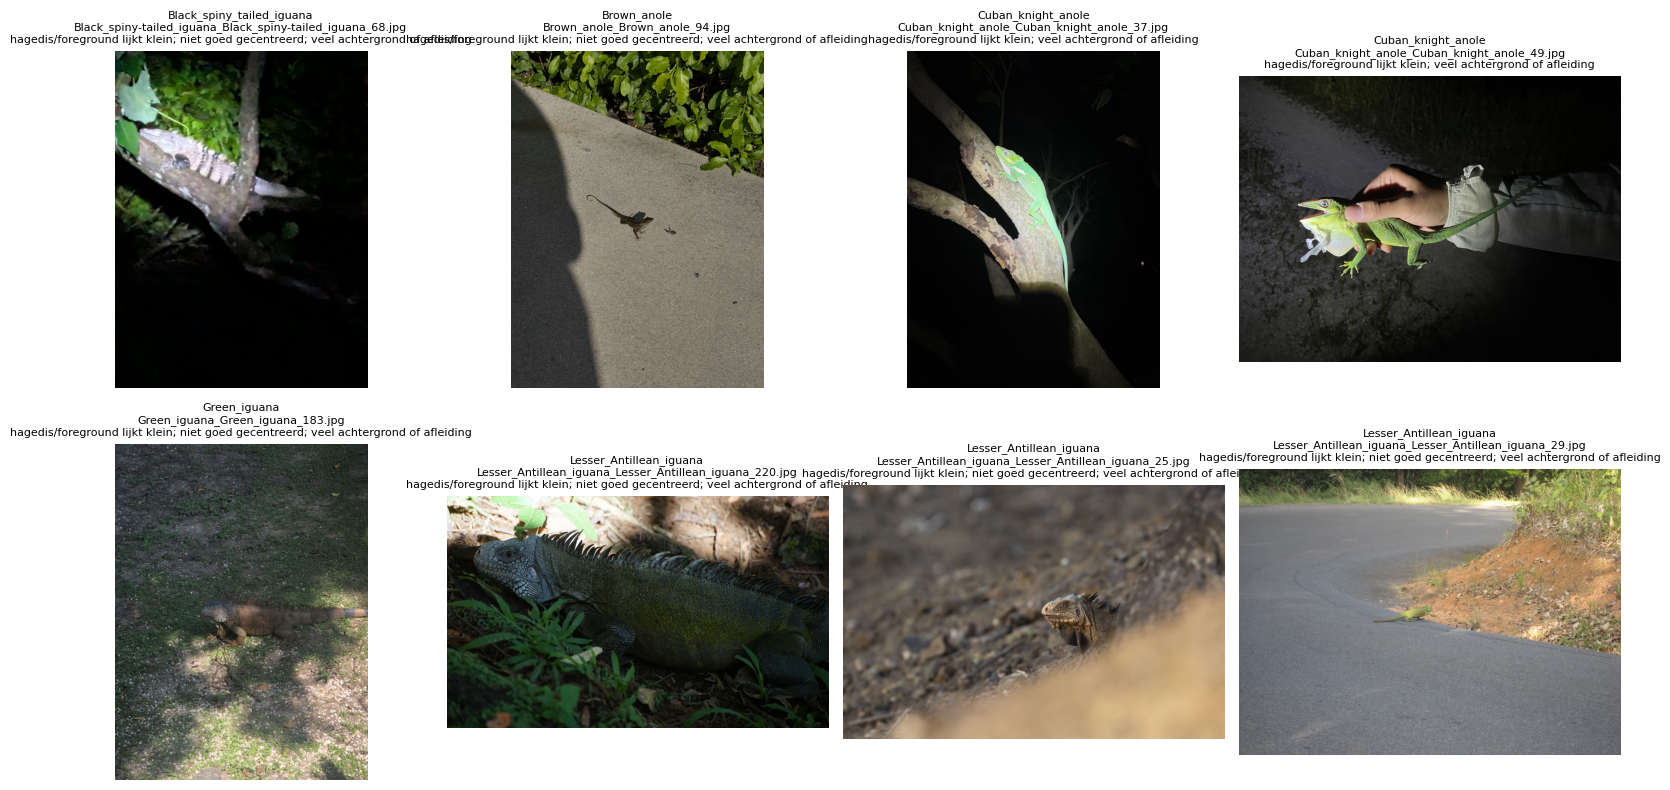

In [10]:
def show_crop_examples(crop_log, max_examples=10):
    if not crop_log:
        print("Geen veilige crops gemaakt.")
        return
    examples = crop_log[:max_examples]
    fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3 * len(examples)))
    if len(examples) == 1:
        axes = np.array([axes])
    for ax_row, item in zip(axes, examples):
        original_path = TRAIN_DIR / item["class"] / item["original"]
        cropped_path = Path(item["path"])
        for ax, image_path, title in [
            (ax_row[0], original_path, "origineel"),
            (ax_row[1], cropped_path, "cropped"),
        ]:
            ax.imshow(Image.open(image_path))
            ax.set_title(f"{title}\n{image_path.name}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_manual_review_images(manual_review_df, max_per_class=MAX_MANUAL_REVIEW_PER_CLASS):
    if manual_review_df.empty:
        print("Geen manuele review nodig.")
        return
    selected = []
    for class_name in CLASS_NAMES:
        part = manual_review_df[manual_review_df["class"] == class_name].head(max_per_class)
        for _, row in part.iterrows():
            path = TRAIN_DIR / row["class"] / row["id"]
            if path.exists():
                selected.append((path, row["reden"]))
    if not selected:
        print("Geen bestaande reviewbeelden gevonden.")
        return

    cols = 4
    rows = int(np.ceil(len(selected) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (image_path, reason) in zip(axes, selected):
        ax.imshow(Image.open(image_path))
        ax.set_title(f"{image_path.parent.name}\n{image_path.name}\n{reason}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(selected):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_crop_examples(crop_log)
show_manual_review_images(manual_review_df)


In [11]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_split["label"].values)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(weights)}
CLASS_WEIGHTS


{0: 0.958670260557053,
 1: 0.9897959183673469,
 2: 1.009460737937559,
 3: 1.044031311154599,
 4: 1.065934065934066,
 5: 0.9708826205641492,
 6: 0.9708826205641492}

## 4. TensorFlow datasets

EfficientNetV2 met `include_preprocessing=True` verwacht RGB-pixels in `[0,255]`.

In [12]:
BATCH_SIZE = 8
IMG_SIZE = (384, 384)      # 384 geeft EfficientNetV2S meer detail; gebruik (300,300) en batch 16 als training te traag is.
BACKBONE = "EfficientNetV2S"  # alternatief: "EfficientNetV2M" voor een zwaardere run
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetV2 krijgt pixelwaarden 0..255; include_preprocessing=True doet de model-specifieke preprocessing.
def load_image(path, label=None, img_size=IMG_SIZE):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32) * 255.0
    image = tf.image.resize(image, img_size)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)

def make_labeled_ds(df, img_size=IMG_SIZE, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

def make_unlabeled_ds(paths, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(np.array(paths, dtype=str))
    ds = ds.map(lambda p: load_image(p, None, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_labeled_ds(train_split, shuffle=True)
val_ds = make_labeled_ds(val_split)


W0000 00:00:1778663950.762374   45140 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 5. Eigen CNN baseline

Deze baseline is vooral voor de minimumvereiste uit de opdracht. Het transfer-learning model zal normaal beter scoren.

In [13]:
def build_own_cnn(input_shape, num_classes):
    return keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.04, 0.04),
        layers.Conv2D(32, 3, padding="same", activation="gelu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="gelu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="gelu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="gelu"), layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.45),
        layers.Dense(256, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-5)),
        layers.Dropout(0.35),
        layers.Dense(128, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-5)),
        layers.Dropout(0.25),
        layers.Dense(num_classes, activation="softmax"),
    ], name="own_cnn_baseline")

cnn_model = build_own_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.compile(optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()


Model: "own_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 384, 384, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 384, 384, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 384, 384, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384, 384, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 489,927 (1.87 MB)

 Trainable params: 488,967 (1.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
TRAIN_OWN_CNN = False
if TRAIN_OWN_CNN:
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_own_cnn.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=35, class_weight=CLASS_WEIGHTS, callbacks=callbacks)
else:
    history_cnn = None
    print("Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.")

Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.


## 6. Transfer learning + fine-tuning

In [15]:
def backbone_class(name):
    if name == "EfficientNetV2S":
        return keras.applications.EfficientNetV2S
    if name == "EfficientNetV2M":
        return keras.applications.EfficientNetV2M
    raise ValueError("Gebruik EfficientNetV2S of EfficientNetV2M")

def build_data_augmentation():
    # Realistische augmentatie voor hagedissen: links/rechts flip kan, rotatie/zoom/contrast blijven beperkt.
    # Geen MixUp/CutMix: labels blijven zuiver en de hagedis blijft visueel herkenbaar.
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10, fill_mode="reflect"),
        layers.RandomZoom(height_factor=(-0.12, 0.18), width_factor=(-0.12, 0.18), fill_mode="reflect"),
        layers.RandomTranslation(0.07, 0.07, fill_mode="reflect"),
        layers.RandomContrast(0.20),
        layers.RandomBrightness(0.10, value_range=(0, 255)),
    ], name="data_augmentation")

def build_transfer_model(backbone_name=BACKBONE, img_size=IMG_SIZE):
    Backbone = backbone_class(backbone_name)
    base = Backbone(include_top=False, weights="imagenet", input_shape=(*img_size, 3), include_preprocessing=True)
    base.trainable = False
    augmentation = build_data_augmentation()
    inputs = keras.Input(shape=(*img_size, 3), name="image")
    x = augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(512, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(192, activation="gelu", kernel_regularizer=keras.regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="species")(x)
    return keras.Model(inputs, outputs, name=f"lizard_{backbone_name}_scoreboost"), base

model, base_model = build_transfer_model()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


Model: "lizard_EfficientNetV2S_scoreboost"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 192)            │        98,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 7)              │         1,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,095,015 (80.47 MB)

 Trainable params: 759,687 (2.90 MB)

 Non-trainable params: 20,335,328 (77.57 MB)

In [ ]:
TRAIN_TRANSFER = True
if TRAIN_TRANSFER:
    callbacks1 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.35, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_phase1.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase1 = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=CLASS_WEIGHTS, callbacks=callbacks1)
else:
    history_phase1 = None

Epoch 1/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 900ms/step - accuracy: 0.3889 - loss: 1.8177 - val_accuracy: 0.5506 - val_loss: 1.2449 - learning_rate: 5.0000e-04
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 875ms/step - accuracy: 0.4873 - loss: 1.4633 - val_accuracy: 0.6742 - val_loss: 0.9007 - learning_rate: 5.0000e-04
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 119s 881ms/step - accuracy: 0.5614 - loss: 1.1951 - val_accuracy: 0.6742 - val_loss: 0.8863 - learning_rate: 5.0000e-04
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 117s 871ms/step - accuracy: 0.5717 - loss: 1.1763 - val_accuracy: 0.6517 - val_loss: 0.9063 - learning_rate: 5.0000e-04
Epoch 5/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 127s 941ms/step - accuracy: 0.6017 - loss: 1.1163 - val_accuracy: 0.7041 - val_loss: 0.8449 - learning_rate: 5.0000e-04
Epoch 6/25
 63/134 ━━━━━━━━━━━━━━━━━━━━ 57s 815ms/step - accuracy: 0.5869 - loss: 1.2165

In [ ]:
if TRAIN_TRANSFER:
    model = keras.models.load_model("scoreboost_phase1.keras")
    backbone = next(layer for layer in model.layers if "efficientnet" in layer.name.lower())
    backbone.trainable = True
    fine_tune_last_n = 80 if BACKBONE == "EfficientNetV2S" else 110
    for layer in backbone.layers[:-fine_tune_last_n]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    lr_schedule = keras.optimizers.schedules.CosineDecay(6e-6, decay_steps=max(1, len(train_split)//BATCH_SIZE)*40, alpha=0.08)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=5e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks2 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("scoreboost_finetuned.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase2 = model.fit(train_ds, validation_data=val_ds, epochs=40, class_weight=CLASS_WEIGHTS, callbacks=callbacks2)
else:
    history_phase2 = None


## 7. Training curves

In [ ]:
def plot_history(history, title):
    if history is None:
        print("Geen history voor", title)
        return
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(hist["accuracy"], label="train")
    axes[0].plot(hist["val_accuracy"], label="validatie")
    axes[0].set_title(title + " accuracy")
    axes[0].legend()
    axes[1].plot(hist["loss"], label="train")
    axes[1].plot(hist["val_loss"], label="validatie")
    axes[1].set_title(title + " loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Eigen CNN")
plot_history(history_phase1, "Transfer fase 1")
plot_history(history_phase2, "Fine-tuning")

## 8. Modelkeuze en confusion matrix

We kiezen niet blind een ensemble. Als een ensemble op validatie slechter is dan het beste losse model, gebruiken we het beste losse model. Zo maken we de Kaggle-submission minder fragiel.

In [ ]:
def predict_model(model_path, paths, img_size):
    m = keras.models.load_model(model_path)
    probs = m.predict(make_unlabeled_ds(paths, img_size=img_size), verbose=0)
    tf.keras.backend.clear_session(); gc.collect()
    return probs

candidate_models = []
if Path("scoreboost_finetuned.keras").exists(): candidate_models.append(("scoreboost_finetuned.keras", IMG_SIZE))
if Path("scoreboost_phase1.keras").exists(): candidate_models.append(("scoreboost_phase1.keras", IMG_SIZE))
for item in [("best_efficientnetv2s_pwp.keras", (260,260)), ("phase1_best_efficientnetv2s_pwp.keras", (260,260)), ("best_model_fase2.keras", (224,224)), ("best_model_fase1.keras", (224,224))]:
    if Path(item[0]).exists(): candidate_models.append(item)

seen=set(); candidate_models=[x for x in candidate_models if not (x[0] in seen or seen.add(x[0]))]
print(candidate_models)

In [ ]:
val_paths = val_split["path"].tolist()
y_true = val_split["label"].to_numpy()
val_probs_list = []
rows = []
for path, size in candidate_models:
    probs = predict_model(path, val_paths, size)
    acc = accuracy_score(y_true, probs.argmax(axis=1))
    val_probs_list.append(probs)
    rows.append({"model": path, "img_size": size, "val_accuracy": acc})

scores = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
display(scores)
best_model_path = scores.iloc[0]["model"]
best_img_size = tuple(scores.iloc[0]["img_size"])
best_index = candidate_models.index((best_model_path, best_img_size))
best_val_probs = val_probs_list[best_index]
best_val_acc = scores.iloc[0]["val_accuracy"]

accs = np.array([r["val_accuracy"] for r in rows])
weights = (accs ** 2) / np.sum(accs ** 2)
ensemble_val_probs = sum(w*p for w, p in zip(weights, val_probs_list))
ensemble_val_acc = accuracy_score(y_true, ensemble_val_probs.argmax(axis=1))
USE_ENSEMBLE = ensemble_val_acc > best_val_acc
print("Best single:", best_model_path, round(best_val_acc,4))
print("Ensemble:", round(ensemble_val_acc,4), "use?", USE_ENSEMBLE)

final_val_probs = ensemble_val_probs if USE_ENSEMBLE else best_val_probs
y_pred = final_val_probs.argmax(axis=1)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout(); plt.show()

# Toon automatisch welke klasses het vaakst met elkaar verward worden.
confusions = []
for true_idx, true_name in enumerate(CLASS_NAMES):
    for pred_idx, pred_name in enumerate(CLASS_NAMES):
        if true_idx == pred_idx:
            continue
        count = int(cm[true_idx, pred_idx])
        if count > 0:
            confusions.append({"true_class": true_name, "predicted_as": pred_name, "count": count})
most_confused = pd.DataFrame(confusions).sort_values("count", ascending=False)
print("Meest verwarde klassen")
display(most_confused.head(15))

if {"Green_anole", "Brown_anole"}.issubset(set(CLASS_NAMES)):
    green_idx = CLASS_NAMES.index("Green_anole")
    brown_idx = CLASS_NAMES.index("Brown_anole")
    print("Green/Brown check:")
    print("Green_anole voorspeld als Brown_anole:", int(cm[green_idx, brown_idx]))
    print("Brown_anole voorspeld als Green_anole:", int(cm[brown_idx, green_idx]))
    print("Als deze waarden hoog zijn: voeg meer duidelijke, veilige crops toe per klasse en controleer labelkwaliteit.")


## 9. Kaggle submission met TTA

In [ ]:
def predict_with_tta(model_path, paths, img_size, num_tta=5):
    m = keras.models.load_model(model_path)
    base_ds = make_unlabeled_ds(paths, img_size=img_size)
    all_probs = []
    for tta_i in range(num_tta):
        parts = []
        for batch in base_ds:
            x = batch
            if tta_i == 1:
                x = tf.image.flip_left_right(batch)
            elif tta_i == 2:
                x = tf.image.adjust_contrast(batch, 1.08)
            elif tta_i == 3:
                x = tf.image.adjust_brightness(batch, 8.0)
            elif tta_i == 4:
                margin_h = max(1, int(img_size[0] * 0.04))
                margin_w = max(1, int(img_size[1] * 0.04))
                cropped = tf.image.crop_to_bounding_box(batch, margin_h, margin_w, img_size[0] - 2*margin_h, img_size[1] - 2*margin_w)
                x = tf.image.resize(cropped, img_size)
            parts.append(m.predict(x, verbose=0))
        all_probs.append(np.concatenate(parts, axis=0))
    tf.keras.backend.clear_session(); gc.collect()
    return np.mean(all_probs, axis=0)

test_paths = test_df["path"].tolist()
NUM_TTA = 5

if USE_ENSEMBLE:
    probs = 0
    for (path, size), weight in zip(candidate_models, weights):
        print("predict", path, "weight", round(float(weight),3))
        probs = probs + weight * predict_with_tta(path, test_paths, size, NUM_TTA)
    output_name = "submission_scoreboost_ensemble_tta.csv"
else:
    print("predict beste model", best_model_path)
    probs = predict_with_tta(best_model_path, test_paths, best_img_size, NUM_TTA)
    output_name = "submission_scoreboost_bestmodel_tta.csv"

submission = pd.DataFrame({"id": sample_sub["id"], "label": probs.argmax(axis=1).astype(int)})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["label"].between(0, NUM_CLASSES-1).all()
submission.to_csv(output_name, index=False)
submission.to_csv("submission.csv", index=False)
print("saved", output_name, "and submission.csv")
display(submission.head(10))
print(submission["label"].value_counts().sort_index())

## 10. Conclusie voor de defense

### Technische controle van de verbeterpunten

1. **Data augmentation: klopt en is toegepast.** De originele augmentation was bruikbaar maar eerder beperkt. De transfer-learning notebook gebruikt nu Keras-layers met realistische flip, rotatie, zoom, translatie, contrast en brightness. Dit gebeurt alleen in het model op `train_ds`, niet op validatie/test.
2. **Image size 384x384: waarschijnlijk nuttig, maar zwaarder.** EfficientNetV2S kan 384x384 aan en kleine hagedissen behouden zo meer detail. Daarom staat `IMG_SIZE = (384, 384)` en `BATCH_SIZE = 8`. Als training te traag is, kan dit terug naar 300x300 en batch 16.
3. **Preprocessing/cropping: deels nuttig, voorzichtig toegepast.** De notebook controleert alle klassen op verdachte beelden. Automatisch croppen gebeurt standaard alleen wanneer je een handmatig gecontroleerde `SAFE_CROP_BOXES` entry toevoegt. Dit voorkomt slechte automatische crops en voorkomt leakage doordat crops pas na de split aan `train_split` worden toegevoegd.
4. **Geen MixUp/CutMix: klopt.** MixUp/CutMix wordt niet gebruikt. Voor deze kleine, soortspecifieke dataset kunnen gemengde beelden labels verwarren, dus gewone augmentation is veiliger.
5. **Dense layers: toegepast.** De transfer head gebruikt nu twee Dense-lagen (`512` en `192`) met dropout, batch normalization en lichte L2-regularisatie.
6. **Activatiefunctie GELU: toegepast.** ReLU is vervangen door GELU in de dense head. GELU is vloeiender dan ReLU en kan bij transfer learning soms net iets stabieler optimaliseren.
7. **Optimizer AdamW: toegepast.** Adam is vervangen door AdamW met weight decay. Fase 1 gebruikt `5e-4` met `1e-4` weight decay; fine-tuning gebruikt een lagere cosine learning rate met `5e-5` weight decay.
8. **Meer augmentation en validatie: toegepast.** Training kan hierdoor moeilijker worden en train accuracy lager lijken, maar validation accuracy kan stabieler worden. Validatie/test krijgen geen augmentation.
9. **Confusion matrix / most confused classes: toegepast.** De notebook toont nu automatisch de meest verwarde klassen en print specifiek hoeveel `Green_anole` en `Brown_anole` met elkaar verwisseld worden. Dit is analyse, geen extra preprocessing-focus.

### GenAI-vermelding

AI werd gebruikt om de PowerPointvereisten te controleren, de notebookstructuur te verbeteren en de technische verbeterpunten te verwerken. De beperking blijft dat een hogere validatiescore geen garantie geeft op een hogere Kaggle-score; de uiteindelijke CSV moet dus op Kaggle getest worden.
